# Cheap LLM judge and baseline scores for NL→FOL faithfulness: demo

This notebook demonstrates **Experiment D (the baseline arm)** from a study of *gold-free* metrics for natural-language → first-order-logic (NL→FOL) translation. The question: given a sentence and a candidate FOL formula, and no gold formula, can a cheap score predict whether the formula is **faithful** to the text?

The original `method.py` is a multi-stage pipeline:

| stage | what it does | needs |
|---|---|---|
| `screen` / `prep` | build the frozen screen of 1,090 items, prover-checked labels, invariance rewrites, **nonce disguise** of every item | z3, spaCy |
| `judges` / `strong` | cheap LLM judges (gemini-2.5-flash-lite JSON 0-100, gpt-4.1-nano P(YES)), frontier judge (gemini-3.1-pro), each on **original** and **disguised** text | OpenRouter API ($2.02 total) |
| `roundtrip` / `rt_equiv` | FOL→NL verbalisation, then NLI both ways, mpnet cosine, and re-formalisation checked with z3 | API + GPU |
| `pilot` | the user's structural pilot metrics (joint conflict, arity, dangling symbols, rerun Jaccard) | z3 |
| **`analysis`** (default) | **rebuilds every table from the cached scores**: AUROC with sentence-cluster bootstrap CIs, paired ΔAUROC + DeLong, contamination (orig vs disguised), cross-fitted baseline combination, T8 sanity checks | numpy / sklearn |

The expensive stages need API keys, a GPU and hours of compute, so this demo **replays the default `--stage analysis`** on a 100-item subset of **track L**: real Logic-LM outputs (gpt-4, gpt-3.5-turbo, text-davinci-003) on FOLIO-dev, labelled CORRECT or ERROR by prover-checked equivalence to corrected gold. Every metric's score comes from the cached per-item outputs of the full run, and every score is **oriented so that higher = more likely unfaithful**.

In the full run (n = 524), the **disguised cheap judge** reaches AUROC **0.777 [0.720, 0.827]**; that is the bar. The cross-fitted combination of all cheap baselines reaches 0.817. The user's structural pilot metrics are near chance (0.50–0.53).

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT pre-installed on Colab, always install
_pip('loguru==0.7.3')

# numpy, scipy, scikit-learn, matplotlib — pre-installed on Colab, install locally only (Colab's exact versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'scipy==1.16.3', 'scikit-learn==1.6.1', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


## Imports

This is the original import block of `method.py`, followed by the imports of `src/analysis.py`, whose helpers the `analysis` stage calls. Changes for the notebook: the log-file sink is dropped (stdout only), and the `NLTK_DATA` default is dropped because it depends on `__file__`. `matplotlib` is added for the final figure.

In [2]:
import argparse
import asyncio
import json
import math
import os
import sys
import time
from collections import Counter, defaultdict
from pathlib import Path

os.environ.setdefault("PYTHONHASHSEED", "0")
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")
sys.setrecursionlimit(10000)

from loguru import logger  # noqa: E402

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")

# imports of src/analysis.py
import numpy as np
from scipy import stats
from sklearn.metrics import average_precision_score, roc_auc_score, roc_curve

# notebook-only: visualisation
import matplotlib.pyplot as plt

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-eff060-layered-gold-free-checks-for-logic/fork/run_e4aqYfQhdCkX/round-1/experiment-4/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["metadata"]["description"])
print(f"{len(data['items'])} items; label vector sha1 {data['metadata']['label_vector_sha1'][:8]}… (full screen)")

100-item demo subset of track L (Logic-LM FOLIO-dev outputs, CORRECT vs ERROR) from the shared frozen screen. oriented_scores: higher = more likely UNFAITHFUL; 'NA' = metric not applicable, 'FAIL' = metric failure.
100 items; label vector sha1 122d01df… (full screen)


## Configuration

These are all the tunable parameters. The original values are the pre-registered ones in `prereg.json`: 2,000 cluster-bootstrap resamples, 5-fold `GroupKFold`, L2 logistic regression with C = 1.0, and 20 label shuffles for the T8 sanity check. The analysis takes seconds, so the demo runs at those values on all 100 demo items. The full run used all 524 track-L CORRECT/ERROR items.

In [5]:
N_ITEMS = 100        # demo items to evaluate (max 100 in mini_demo_data.json; full run: 524 track-L CORRECT/ERROR items)
B_RESAMPLES = 2000   # sentence-cluster bootstrap resamples (original: 2000)
SEED = 0             # bootstrap / shuffle seed (original: 0)
N_SPLITS = 5         # GroupKFold folds for the cross-fitted combination (original: 5)
C_REG = 1.0          # L2 logistic-regression strength for the combination (original: 1.0)
N_SHUFFLES = 20      # label permutations in the T8 sanity check (original: 20)

## Shared helpers (`src/common.py`, `src/analysis.py`)

`method.py` imports these helpers from its `src/` package. They are copied here verbatim so the notebook runs on its own. The only change is that `B_RESAMPLES` and `SEED` come from the config cell.

- `norm` normalises a sentence. Normalised text is the **cluster id**: the same FOLIO sentence translated by 3 systems forms one cluster, and bootstrap resamples and CV folds never split a cluster.
- `METRICS` registers every baseline. Its *kind* sets the flagging threshold: `prob` for judges (flag if P(faithful) < 0.5), `bin` for binary flags, `count` (flag if > 0), and `cont` (flag above the 90th percentile of track-H CORRECT items).
- `NA` means a metric does not apply by design. `FAIL` means the metric failed; it is scored as the maximum (flagged) and counted against coverage, so failures are never silently dropped.

In [6]:
# ---- src/common.py
import re
_QUOTES = str.maketrans({"‘": "'", "’": "'", "“": '"', "”": '"', "–": "-", "—": "-", "−": "-"})


def norm(s: str) -> str:
    s = (s or "").translate(_QUOTES).lower()
    s = re.sub(r"[^\w\s]", " ", s)
    return re.sub(r"\s+", " ", s).strip()


# ---- src/analysis.py
# name -> (source description, kind) ; kind: prob (judge, thr 0.5) | cont (percentile thr) | bin (>0.5) | count (>0)
METRICS = {
    "parse_fail": ("1 - parses under the shared FOL grammar + z3", "bin"),
    "pilot_joint_conflict": ("story ∪ {cand} UNSAT (z3)", "bin"),
    "pilot_arity_incons": ("#arity clashes with story / within cand", "count"),
    "pilot_shape_incons": ("#arg-kind shape clashes with story", "count"),
    "pilot_dangling": ("fraction of cand symbols absent from story", "cont"),
    "pilot_undeclared": ("fraction of cand predicates not declared (Logic-LM)", "count"),
    "pilot_rerun_jacc": ("1 - cross-system predicate Jaccard (rerun proxy)", "cont_L"),
    "rt_nli_min": ("1 - min(P_entail fwd, bwd)", "cont"),
    "rt_nli_fwd": ("1 - P_entail(text => verbalisation)", "cont"),
    "rt_nli_bwd": ("1 - P_entail(verbalisation => text)", "cont"),
    "rt_nli_contra": ("max P_contradiction", "cont"),
    "rt_nli_min_alt": ("1 - min entail, alt NLI checkpoint", "cont"),
    "rt_embed_cos": ("1 - mpnet cosine(text, verbalisation)", "cont"),
    "rt_reformalise_eq": ("1 - [re-formalised verbalisation ≡ cand modulo vocab]", "bin"),
    "judge_cheap_orig": ("1 - P(faithful), primary cheap judge, original", "prob"),
    "judge_cheap_disg": ("1 - P(faithful), primary cheap judge, DISGUISED (pre-registered bar)", "prob"),
    "judge_cheap2_orig": ("1 - P(YES), secondary judge logprobs, original", "prob"),
    "judge_cheap2_disg": ("1 - P(YES), secondary judge logprobs, disguised", "prob"),
    "judge_strong_orig": ("1 - P(faithful), strong (frontier) judge, original (subset)", "prob"),
    "judge_strong_disg": ("1 - P(faithful), strong (frontier) judge, disguised (subset)", "prob"),
    # secondary: open-weight local judges / local verbaliser (run while the API key was exhausted)
    "judge_local_qwen8b_orig": ("1 - P(faithful), local Qwen3-8B JSON judge, original", "prob"),
    "judge_local_qwen8b_disg": ("1 - P(faithful), local Qwen3-8B JSON judge, disguised", "prob"),
    "judge_local_llama8b_orig": ("1 - P(YES), local Llama-3.1-8B logprob judge, original", "prob"),
    "judge_local_llama8b_disg": ("1 - P(YES), local Llama-3.1-8B logprob judge, disguised", "prob"),
    "judge_local_qwen14b_orig": ("1 - P(faithful), local Qwen3-14B-nf4 judge, original (subset)", "prob"),
    "judge_local_qwen14b_disg": ("1 - P(faithful), local Qwen3-14B-nf4 judge, disguised (subset)", "prob"),
    "rt_nli_min_localverb": ("1 - min NLI entail, local Qwen3-8B verbaliser", "cont"),
    "rt_reformalise_eq_localverb": ("1 - re-formalisation equivalence, local Qwen3-8B verbaliser", "bin"),
}
SUBSET_METRICS = {"judge_strong_orig", "judge_strong_disg", "judge_local_qwen14b_orig", "judge_local_qwen14b_disg"}
NA = "NA"      # not applicable by design (excluded from that metric's evaluation)
FAIL = "FAIL"  # metric failure: scored as the maximum (flagged) and counted against coverage


def fill(values: list, maxval: float) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """-> scores (FAIL -> maxval), applicable mask, fail mask."""
    s = np.array([maxval if v == FAIL else (np.nan if v == NA else v) for v in values], dtype=float)
    app = np.array([v != NA for v in values])
    fl = np.array([v == FAIL for v in values])
    return s, app, fl

### Bootstrap, AUROC and DeLong machinery (`src/analysis.py`, verbatim)

`ClusterBoot` draws **sentence clusters** with replacement. Every metric uses the *same* resamples, so paired ΔAUROC CIs are valid. `boot_auc` computes the tie-aware (ties = 0.5) weighted AUROC for all B resamples in one vectorised pass. `delong` is the fast paired DeLong test (Sun & Xu 2014).

In [7]:
class ClusterBoot:
    """Cluster bootstrap weights: each resample draws clusters with replacement; item weight = cluster multiplicity."""

    def __init__(self, clusters: list[str], B: int = B_RESAMPLES, seed: int = SEED):
        self.uc = sorted(set(clusters))
        idx = {c: i for i, c in enumerate(self.uc)}
        self.cid = np.array([idx[c] for c in clusters])
        rng = np.random.default_rng(seed)
        draws = rng.integers(0, len(self.uc), size=(B, len(self.uc)))
        self.W = np.zeros((B, len(self.uc)), dtype=np.int32)
        for b in range(B):
            np.add.at(self.W[b], draws[b], 1)
        self.B = B

    def item_weights(self, b: int) -> np.ndarray:
        return self.W[b][self.cid]


def auc_w(y, s, w=None):
    ok = ~np.isnan(s)
    y, s = y[ok], s[ok]
    w = None if w is None else w[ok]
    if w is not None:
        keep = w > 0
        y, s, w = y[keep], s[keep], w[keep]
    if len(np.unique(y)) < 2:
        return np.nan
    return roc_auc_score(y, s, sample_weight=w)


def boot_auc(y, s, cb: ClusterBoot):
    """Vectorised weighted AUROC (ties = 0.5) for all B cluster-bootstrap resamples at once."""
    ok = ~np.isnan(s)
    if ok.sum() == 0 or len(np.unique(y[ok])) < 2:
        return np.full(cb.B, np.nan)
    s_, y_, cid = s[ok], y[ok], cb.cid[ok]
    Wi = cb.W[:, cid].astype(np.float64)                      # B x n item weights
    u, inv = np.unique(s_, return_inverse=True)                # ascending unique scores
    K = len(u)
    onehot = np.zeros((len(s_), K))
    onehot[np.arange(len(s_)), inv] = 1.0
    P = Wi[:, y_ == 1] @ onehot[y_ == 1]                       # B x K positive weight per unique score
    N = Wi[:, y_ == 0] @ onehot[y_ == 0]
    cumN_before = np.cumsum(N, axis=1) - N
    num = (P * (cumN_before + 0.5 * N)).sum(1)
    den = P.sum(1) * N.sum(1)
    with np.errstate(invalid="ignore", divide="ignore"):
        out = np.where(den > 0, num / den, np.nan)
    return out


def ci(a):
    a = a[~np.isnan(a)]
    if len(a) == 0:
        return [None, None]
    return [float(np.percentile(a, 2.5)), float(np.percentile(a, 97.5))]


def tie_rate(y, s):
    ok = ~np.isnan(s)
    pos, neg = s[ok & (y == 1)], s[ok & (y == 0)]
    if len(pos) == 0 or len(neg) == 0:
        return None
    # count tied (pos, neg) pairs via value counts
    cp, cn = Counter(pos.round(9).tolist()), Counter(neg.round(9).tolist())
    ties = sum(cp[v] * cn.get(v, 0) for v in cp)
    return ties / (len(pos) * len(neg))


def delong(y, s1, s2):
    """Paired DeLong test for two correlated AUCs (Sun & Xu 2014 fast version). Returns (auc1, auc2, z, p)."""
    ok = ~np.isnan(s1) & ~np.isnan(s2)
    y, s1, s2 = y[ok], s1[ok], s2[ok]
    pos, neg = y == 1, y == 0
    m, n = pos.sum(), neg.sum()
    if m < 2 or n < 2:
        return None

    def comps(s):
        x, yv = s[pos], s[neg]
        v10 = np.array([(np.sum(xi > yv) + 0.5 * np.sum(xi == yv)) / n for xi in x])
        v01 = np.array([(np.sum(x > yj) + 0.5 * np.sum(x == yj)) / m for yj in yv])
        return v10.mean(), v10, v01
    a1, v10a, v01a = comps(s1)
    a2, v10b, v01b = comps(s2)
    s10 = np.cov(np.vstack([v10a, v10b]))
    s01 = np.cov(np.vstack([v01a, v01b]))
    S = s10 / m + s01 / n
    var = S[0, 0] + S[1, 1] - 2 * S[0, 1]
    if var <= 0:
        return float(a1), float(a2), 0.0, 1.0
    z = (a1 - a2) / math.sqrt(var)
    return float(a1), float(a2), float(z), float(2 * (1 - stats.norm.cdf(abs(z))))

### Thresholded operating point and per-set evaluation (`src/analysis.py`, verbatim)

`at_threshold` reports precision, recall, false-alarm rate and balanced accuracy at the pre-registered threshold, plus precision re-weighted to 10% and 25% error prevalence. `evaluate_set` runs every metric on one evaluation set. A result is marked `testable` only with ≥ 50 items per class, so on this 100-item demo most numbers are *descriptive*.

In [8]:
def thresholds(scores_by_metric: dict, ref_mask_by_metric: dict) -> dict:
    """judges 0.5 on oriented scale; continuous -> 90th pct of oriented score on the reference (track-H CORRECT, dev
    excluded); binary -> 0.5; counts -> 0 (flag if >0); L-only continuous (rerun jacc) -> 0.5 (Jaccard < 0.5)."""
    thr = {}
    for m, (_, kind) in METRICS.items():
        if kind == "prob" or kind == "bin":
            thr[m] = 0.5
        elif kind == "count":
            thr[m] = 0.0
        elif kind == "cont_L":
            thr[m] = 0.5
        else:
            s = scores_by_metric[m]
            ref = s[ref_mask_by_metric[m] & ~np.isnan(s)]
            thr[m] = float(np.percentile(ref, 90)) if len(ref) else 0.5
    return thr


def at_threshold(y, s, t):
    ok = ~np.isnan(s)
    y, s = y[ok], s[ok]
    f = s > t
    tp, fp = int(np.sum(f & (y == 1))), int(np.sum(f & (y == 0)))
    P, N = int(np.sum(y == 1)), int(np.sum(y == 0))
    rec = tp / P if P else None
    fa = fp / N if N else None
    prec = tp / (tp + fp) if (tp + fp) else None

    def rw(pi):
        if rec is None or fa is None or (rec * pi + fa * (1 - pi)) == 0:
            return None
        return rec * pi / (rec * pi + fa * (1 - pi))
    return {"precision": prec, "recall": rec, "fa": fa, "bal_acc": None if rec is None or fa is None else (rec + 1 - fa) / 2,
            "prec_at_10pct": rw(0.10), "prec_at_25pct": rw(0.25), "n_flagged": int(f.sum())}


def evaluate_set(name, keys, y, table, thr, metrics, cb=None, compute_ci=True):
    """-> ({metric: result}, cb, {metric: boot array})."""
    clusters = [table["_cluster"][k] for k in keys]
    if cb is None and compute_ci:
        cb = ClusterBoot(clusters)
    res, boots = {}, {}
    for m in metrics:
        vals = [table[m][k] for k in keys]
        mx = table["_max"][m]
        s, app, fl = fill(vals, mx)
        s_app = np.where(app, s, np.nan)
        n_app = int(app.sum())
        if n_app == 0 or len(np.unique(y[app])) < 2:
            res[m] = {"n_applicable": n_app, "auroc": None, "note": "not applicable / single class"}
            continue
        a = auc_w(y, s_app)
        r = {"n_applicable": n_app, "n_pos": int(np.sum(y[app] == 1)), "n_neg": int(np.sum(y[app] == 0)),
             "prevalence": float(np.mean(y[app])), "auroc": float(a),
             "auprc": float(average_precision_score(y[app], s[app])), "tie_rate": tie_rate(y, s_app),
             "coverage": float(1 - fl[app].mean()), "n_fail": int(fl[app].sum()), "threshold": thr[m],
             **at_threshold(y, s_app, thr[m])}
        r["testable"] = bool(r["n_pos"] >= 50 and r["n_neg"] >= 50)
        if compute_ci:
            ba = boot_auc(y, s_app, cb)
            boots[m] = ba
            r["auroc_ci"] = ci(ba)
        res[m] = r
    return res, cb, boots

### Cross-fitted baseline combination (`src/analysis.py`, verbatim)

`combo_oof` fits a standardised L2 logistic regression on a feature set, using **out-of-fold** predictions with `GroupKFold` by sentence. A missing feature becomes 0 plus a missing-indicator column. The best of the pre-registered feature sets (S1 structural, S2 round-trip, S3 disguised judges, S4 all cheap) gives `best_baseline_oof`, the second bar that any new metric must beat.

In [9]:
def combo_oof(keys, y, groups, table, feats, n_splits=N_SPLITS, C=C_REG, fold_of=None):
    from sklearn.linear_model import LogisticRegression
    from sklearn.model_selection import GroupKFold
    from sklearn.preprocessing import StandardScaler
    X, cols = [], []
    for f in feats:
        v = [table[f][k] for k in keys]
        s, app, fl = fill(v, table["_max"][f])
        miss = np.isnan(s)
        X.append(np.where(miss, np.nan, s))
        cols.append(f)
        if miss.any():
            X.append(miss.astype(float))
            cols.append(f + "__missing")
    X = np.vstack(X).T
    if fold_of is None:
        gkf = GroupKFold(n_splits=n_splits)
        fold = np.zeros(len(keys), dtype=int)
        for i, (_, te) in enumerate(gkf.split(X, y, groups)):
            fold[te] = i
    else:
        fold = np.array([fold_of[k] for k in keys])
    oof = np.zeros(len(keys))
    for i in range(n_splits):
        tr, te = fold != i, fold == i
        Xtr, Xte = X[tr].copy(), X[te].copy()
        mu = np.nanmean(Xtr, 0)
        mu = np.where(np.isnan(mu), 0, mu)
        sd = np.nanstd(Xtr, 0)
        sd = np.where((sd == 0) | np.isnan(sd), 1, sd)
        Xtr = np.nan_to_num((Xtr - mu) / sd)
        Xte = np.nan_to_num((Xte - mu) / sd)
        clf = LogisticRegression(C=C, max_iter=2000)
        clf.fit(Xtr, y[tr])
        oof[te] = clf.predict_proba(Xte)[:, 1]
    return oof, fold, cols

## The frozen screen (`method.py`: `screen_items`, `_auroc`)

In the original, `screen_items()` reads `data/screen_items.json`. Here it returns the first `N_ITEMS` demo items. Each item has the sentence, the system's candidate FOL, the reference (corrected) gold FOL, and the prover-checked label. `auto_class` records how the label was reached: `EQUIV` = z3-equivalent to the gold; `VOCAB`/`GRAN` = equivalent modulo a vocabulary or granularity mapping, so still CORRECT; otherwise the repair operations needed to reach the gold (`repair_ops`).

In [10]:
def screen_items() -> list[dict]:
    return data["items"][:N_ITEMS]  # original: jload(DATA / "screen_items.json")


def _auroc(y, s):
    from sklearn.metrics import roc_auc_score
    import numpy as np
    y, s = np.asarray(y), np.asarray(s, dtype=float)
    ok = ~np.isnan(s)
    if len(set(y[ok])) < 2:
        return float("nan")
    return float(roc_auc_score(y[ok], s[ok]))


items = screen_items()
print(f"{len(items)} items | labels {dict(Counter(r['label'] for r in items))} | systems {dict(Counter(r['system'] for r in items))}")
print(f"auto_class {dict(Counter(r['auto_class'] for r in items))}")
print(f"ERROR repair ops {dict(Counter('+'.join(r['repair_ops'] or []) for r in items if r['label'] == 'ERROR'))}")
for r in [next(r for r in items if r["label"] == l) for l in ("CORRECT", "ERROR")]:
    print(f"\n[{r['label']}] {r['system']}: {r['text']}\n  candidate: {r['candidate_fol']}\n  reference: {r['reference_fol']}")

100 items | labels {'CORRECT': 56, 'ERROR': 44} | systems {'gpt-4': 41, 'gpt-3.5-turbo': 29, 'text-davinci-003': 30}
auto_class {'VOCAB': 26, 'ERROR': 44, 'GRAN': 3, 'EQUIV': 27}
ERROR repair ops {'ADD+DROP': 24, 'BIND+BIND': 1, 'NEG': 4, 'ADD': 8, 'SWAP': 2, 'DROP': 3, 'BIND': 2}

[CORRECT] gpt-4: Walden contains knowledge.
  candidate: Contain(walden, knowledge)
  reference: Contains(walden, knowledge)

[ERROR] gpt-3.5-turbo: Taylor visits the gym at least once a day.
  candidate: VisitGym(taylor)
  reference: VisitDaily(taylor, gym)


## What the judges see: original vs **disguised** (`method.py`: `_judge_units`)

Every item is judged twice. The second time, every content word in the text and every predicate name in the formula is replaced by a consistent **nonce word**, so structure is kept and lexical meaning is removed. If a judge had *memorised* the public FOLIO gold, the disguise should hurt it more on public gold than on system outputs. That difference is the contamination test. `_judge_units` builds the `(key, text, fol)` units sent to the judges. There are no invariance rewrites in the demo, so `rws=[]`. The API calls themselves (`J.judge_json`, `J.judge_logprob`) are not re-run; their cached outputs are in `oriented_scores`.

In [11]:
def _judge_units(items, rws, dmap, limit):
    """[(key, text, fol)] for orig and disg conditions of screen items and rewrites."""
    its = items[:limit] if limit else items
    rs = rws[:limit] if limit else rws
    units = []
    for r in its:
        d = dmap[r["item_id"]]
        units.append((f"{r['item_id']}|orig", r["text"], r["candidate_fol"]))
        units.append((f"{r['item_id']}|disg", d["text_d"], d["fol_d"]))
    for r in rs:
        d = dmap[r["rw_id"]]
        units.append((f"{r['rw_id']}|orig", r["text"], r["candidate_fol"]))
        units.append((f"{r['rw_id']}|disg", d["text_d"], d["fol_d"]))
    return units


dmap = {r["item_id"]: {"text_d": r["text_d"], "fol_d": r["fol_d"]} for r in items}  # original: data/disguise_map.json
units = _judge_units(items, [], dmap, None)
print(f"cheap judges would be called on {len(units)} units ({len(items)} items x orig/disg)")
for k, t, f in units[:2]:
    print(f"\n{k}\n  text: {t}\n  fol : {f}")
r0 = items[0]
print(f"\njudge_cheap (orig) said type={r0['judge_cheap_type']!r}: {r0['judge_cheap_reason']}")
print(f"round-trip verbalisation: {r0['rt_verbalisation']}")

cheap judges would be called on 200 units (100 items x orig/disg)

d4210026d53bb766|orig
  text: Walden contains knowledge.
  fol : Contain(walden, knowledge)

d4210026d53bb766|disg
  text: Bulifi fosulos mopkeka.
  fol : Fosulo(bulifi, mopkeka)

judge_cheap (orig) said type='NONE': The formula directly translates the sentence's assertion that Walden possesses knowledge.
round-trip verbalisation: Walden contains knowledge.


## Assemble the oriented score table (`src/report.py`: `run`)

This mirrors the start of `report.run`. It builds `table[metric][item] = oriented score | NA | FAIL`, the sentence cluster of every item, and the per-metric maximum that a `FAIL` is scored as. In the full run, thresholds for continuous metrics are the 90th percentile of the oriented score on track-H CORRECT items (`thresholds(...)`, a 10% false-alarm target). Those items are not in this demo, so the **pre-registered thresholds of the full run** are loaded from the data. `_max` is computed over the demo items (in the full run: over all screen items and rewrites).

In [12]:
keys_all = [r["item_id"] for r in items]
byid = {r["item_id"]: r for r in items}
# rows = assemble(...) in the original: here the per-item oriented scores are read from the cached outputs
rows = {r["item_id"]: r["oriented_scores"] for r in items}
# table: metric -> key -> value ; cluster ; max
table = {m: {k: rows[k][m] for k in keys_all} for m in METRICS}
table["_cluster"] = {k: norm(byid[k]["text"]) for k in keys_all}
table["_max"] = {}
for m in METRICS:
    vals = [v for v in table[m].values() if v not in (NA, FAIL)]
    table["_max"][m] = max(vals) if vals else 1.0
    if METRICS[m][1] in ("prob", "bin", "cont", "cont_L") and table["_max"][m] < 1.0 and m != "pilot_dangling":
        table["_max"][m] = max(table["_max"][m], 1.0)
thr = data["metadata"]["thresholds"]  # original: thresholds(sc_h, msk_h) on track-H CORRECT (dev slice excluded)
A = {"thresholds": thr, "metric_definitions": {m: d for m, (d, _) in METRICS.items()}}
print(f"{len(table['_cluster'])} items in {len(set(table['_cluster'].values()))} sentence clusters")
print("FAIL cells per metric:", {m: sum(v == FAIL for v in table[m].values()) for m in METRICS if any(v == FAIL for v in table[m].values())})

100 items in 75 sentence clusters
FAIL cells per metric: {'rt_reformalise_eq': 2, 'judge_cheap_disg': 4, 'rt_reformalise_eq_localverb': 22}


## Item-level evaluation on track L (`report.run`: evaluation sets)

`L_primary` is the headline set: **CORRECT (0) vs ERROR (1)**. UNCERTAIN and UNPARSEABLE items are excluded here, and the full run covers them in sensitivity sets. `L_strong_subset` holds the items that also have frontier-judge scores (200 L items in the full run). For every metric we report AUROC with its 95% sentence-cluster bootstrap CI, AUPRC, tie rate, coverage, and the false-alarm and recall rates at the pre-registered threshold.

In [13]:
L = [r for r in items if r["track"] == "L"]
sets = {
    "L_primary": [(r["item_id"], 1 if r["label"] == "ERROR" else 0) for r in L if r["label"] in ("CORRECT", "ERROR")],
    "L_exclude_subst_only": [(r["item_id"], 1 if r["label"] == "ERROR" else 0) for r in L
                             if r["label"] in ("CORRECT", "ERROR") and not r["subst_only"]],
}
sub_ids = {r["item_id"] for r in items if r["oriented_scores"]["judge_strong_orig"] != NA}  # original: prereg strong_subsample
sets["L_strong_subset"] = [(k, y) for k, y in sets["L_primary"] if k in sub_ids]
results, boots, cbs = {}, {}, {}
t0 = time.time()
for sname, ky in sets.items():
    keys = [k for k, _ in ky]
    y = np.array([v for _, v in ky])
    mets = list(METRICS)
    res, cb, bt = evaluate_set(sname, keys, y, table, thr, mets)
    results[sname] = {"n": len(keys), "n_pos": int(y.sum()), "n_neg": int((1 - y).sum()), "metrics": res}
    boots[sname], cbs[sname] = bt, cb
    logger.info(f"set {sname}: n={len(keys)} pos={int(y.sum())}")
A["sets"] = results
logger.info(f"evaluation with B={B_RESAMPLES} resamples took {time.time()-t0:.1f}s")


def fmt(a, c=None):
    if a is None or (isinstance(a, float) and np.isnan(a)):
        return "—"
    return f"{a:.3f}" + (f" [{c[0]:.3f}, {c[1]:.3f}]" if c and c[0] is not None else "")


R = results["L_primary"]
print(f"\nL_primary (n={R['n']}, errors={R['n_pos']}, correct={R['n_neg']})")
print(f"{'metric':28s} {'AUROC [95% CI]':26s} {'AUPRC':>6s} {'ties':>5s} {'FA@thr':>7s} {'rec@thr':>7s} {'cover':>6s}")
for m, r in R["metrics"].items():
    if r.get("auroc") is None:
        continue
    print(f"{m:28s} {fmt(r['auroc'], r.get('auroc_ci')):26s} {r['auprc']:6.3f} {(r['tie_rate'] or 0):5.2f} "
          f"{fmt(r['fa']):>7s} {fmt(r['recall']):>7s} {r['coverage']:6.3f}")

11:04:03|INFO   |set L_primary: n=100 pos=44


11:04:04|INFO   |set L_exclude_subst_only: n=76 pos=20


11:04:04|INFO   |set L_strong_subset: n=29 pos=6


11:04:04|INFO   |evaluation with B=2000 resamples took 1.7s



L_primary (n=100, errors=44, correct=56)
metric                       AUROC [95% CI]              AUPRC  ties  FA@thr rec@thr  cover
parse_fail                   0.500 [0.500, 0.500]        0.440  1.00   0.000   0.000  1.000
pilot_joint_conflict         0.496 [0.453, 0.541]        0.438  0.91   0.054   0.045  1.000
pilot_arity_incons           0.500 [0.500, 0.500]        0.440  1.00   0.000   0.000  1.000
pilot_shape_incons           0.569 [0.469, 0.674]        0.514  0.45   0.375   0.477  1.000
pilot_dangling               0.437 [0.327, 0.550]        0.436  0.25   0.179   0.182  1.000
pilot_undeclared             0.511 [0.500, 0.537]        0.453  0.98   0.000   0.023  1.000
pilot_rerun_jacc             0.696 [0.581, 0.802]        0.639  0.10   0.111   0.395  1.000
rt_nli_min                   0.737 [0.621, 0.842]        0.737  0.00   0.196   0.409  1.000
rt_nli_fwd                   0.648 [0.530, 0.763]        0.594  0.00   0.161   0.295  1.000
rt_nli_bwd                   0.731 [0.

## Paired ΔAUROC against the bar (`report.run`: `paired`)

Every metric is compared with **`judge_cheap_disg`**, the pre-registered bar. The paired bootstrap Δ uses the same cluster resamples for both metrics, and a DeLong p-value is computed on the items where both apply. On the strong subset, the frontier judge is compared with the cheap judge on the same items.

In [14]:
def paired(sname, ref="judge_cheap_disg", others=None):
    ky = sets[sname]
    keys = [k for k, _ in ky]
    y = np.array([v for _, v in ky])
    bt = boots[sname]
    out = {}
    s_ref, a_ref, _ = fill([table[ref][k] for k in keys], table["_max"][ref])
    for m in (others or bt):
        if m == ref or m not in bt or ref not in bt:
            continue
        d = bt[m] - bt[ref]
        s_m, a_m, _ = fill([table[m][k] for k in keys], table["_max"][m])
        both = a_ref & a_m
        dl = delong(y[both], s_m[both], s_ref[both]) if both.sum() > 10 else None
        out[m] = {"delta_auroc": results[sname]["metrics"][m]["auroc"] - results[sname]["metrics"][ref]["auroc"],
                  "ci": ci(d), "p_boot_le0": float(np.mean(d[~np.isnan(d)] <= 0)) if np.any(~np.isnan(d)) else None,
                  "delong": None if dl is None else {"auc_m": dl[0], "auc_ref": dl[1], "z": dl[2], "p": dl[3]},
                  "note": "metric applicable only on a subset" if both.sum() < len(keys) else ""}
    return out


A["paired_vs_judge_cheap_disg"] = {s: paired(s) for s in ("L_primary", "L_exclude_subst_only")}
A["paired_strong_subset"] = {s: {ref: paired(s, ref=ref, others=["judge_strong_orig", "judge_strong_disg"])
                                 for ref in ("judge_cheap_orig", "judge_cheap_disg")} for s in ("L_strong_subset",)}

print("Paired ΔAUROC vs judge_cheap_disg (L_primary)")
print(f"{'metric':28s} {'ΔAUROC':>7s}  {'95% CI':18s} {'DeLong p':>8s}")
for m, v in A["paired_vs_judge_cheap_disg"]["L_primary"].items():
    c = v["ci"]
    cs = f"[{c[0]:+.3f}, {c[1]:+.3f}]" if c[0] is not None else "—"
    print(f"{m:28s} {v['delta_auroc']:+7.3f}  {cs:18s} {(v['delong'] or {}).get('p', float('nan')):8.3f}")
print("\nStrong (frontier) judge vs cheap judge on the same items (L_strong_subset):")
for ref, per in A["paired_strong_subset"]["L_strong_subset"].items():
    for m, v in per.items():
        print(f"  {m} − {ref}: {v['delta_auroc']:+.3f} CI {[round(x, 3) if x is not None else None for x in v['ci']]} "
              f"DeLong p={(v['delong'] or {}).get('p', float('nan')):.3f}")

Paired ΔAUROC vs judge_cheap_disg (L_primary)
metric                        ΔAUROC  95% CI             DeLong p
parse_fail                    -0.282  [-0.376, -0.178]      0.000
pilot_joint_conflict          -0.286  [-0.384, -0.183]      0.000
pilot_arity_incons            -0.282  [-0.376, -0.178]      0.000
pilot_shape_incons            -0.213  [-0.343, -0.087]      0.001
pilot_dangling                -0.346  [-0.510, -0.187]      0.000
pilot_undeclared              -0.271  [-0.367, -0.168]      0.000
pilot_rerun_jacc              -0.087  [-0.225, +0.043]      0.234
rt_nli_min                    -0.045  [-0.189, +0.092]      0.443
rt_nli_fwd                    -0.135  [-0.278, +0.004]      0.031
rt_nli_bwd                    -0.051  [-0.199, +0.090]      0.405
rt_nli_contra                 -0.145  [-0.295, +0.002]      0.030
rt_nli_min_alt                -0.046  [-0.187, +0.089]      0.421
rt_embed_cos                  -0.089  [-0.242, +0.060]      0.182
rt_reformalise_eq             

## Disguise effect (`report.run`: contamination, track-L part)

For each judge this cell reports the AUROC change from original to disguised input (Δ = disg − orig), with a paired bootstrap CI. In the full run this Δ on track L is compared with the Δ on public track-H gold (a difference-in-differences). Every DiD CI included 0, so there was **no evidence of contamination**. The frontier judge loses about 0.07 under disguise on *both* tracks, which fits lost lexical meaning rather than memorisation.

In [15]:
cont = {}
for judge in ("judge_cheap", "judge_cheap2", "judge_strong", "judge_local_qwen8b", "judge_local_llama8b", "judge_local_qwen14b"):
    cj = {}
    subset_j = judge in ("judge_strong", "judge_local_qwen14b")
    for sname in (("L_primary",) if not subset_j else ("L_strong_subset",)):
        bt = boots[sname]
        o, d = f"{judge}_orig", f"{judge}_disg"
        if o not in bt or d not in bt:
            continue
        delta = bt[d] - bt[o]
        cj[sname] = {"auroc_orig": results[sname]["metrics"][o]["auroc"], "auroc_disg": results[sname]["metrics"][d]["auroc"],
                     "delta_disg_minus_orig": results[sname]["metrics"][d]["auroc"] - results[sname]["metrics"][o]["auroc"],
                     "ci": ci(delta)}
    cont[judge] = cj
A["contamination"] = cont
for j, cj in cont.items():
    for k, v in cj.items():
        print(f"{j:22s} {k:16s} AUROC orig {v['auroc_orig']:.3f} → disg {v['auroc_disg']:.3f} "
              f"(Δ {v['delta_disg_minus_orig']:+.3f}, CI [{v['ci'][0]:+.3f}, {v['ci'][1]:+.3f}])")

judge_cheap            L_primary        AUROC orig 0.788 → disg 0.782 (Δ -0.006, CI [-0.103, +0.086])
judge_cheap2           L_primary        AUROC orig 0.755 → disg 0.755 (Δ +0.000, CI [-0.148, +0.135])
judge_strong           L_strong_subset  AUROC orig 0.942 → disg 0.833 (Δ -0.109, CI [-0.232, -0.013])
judge_local_qwen8b     L_primary        AUROC orig 0.787 → disg 0.773 (Δ -0.013, CI [-0.126, +0.097])
judge_local_llama8b    L_primary        AUROC orig 0.761 → disg 0.692 (Δ -0.069, CI [-0.214, +0.082])
judge_local_qwen14b    L_strong_subset  AUROC orig 0.804 → disg 0.819 (Δ +0.014, CI [-0.164, +0.256])


## Best cross-fitted baseline combination (`report.run`: baseline combination)

This fits the pre-registered feature sets from `prereg.json` out-of-fold. The first set fixes the fold assignment and every later set reuses it (the full run saved it as `data/folds.json`). The best of S1–S4 is `best_baseline_oof`, and its paired Δ against `judge_cheap_disg` tells whether the combined cheap baselines beat the judge. In the full run: S4 0.817 [0.762, 0.867], Δ +0.039 [−0.010, 0.087], not significant.

In [16]:
fs = data["metadata"]["combination_feature_sets"]  # original: prereg["combination_feature_sets"]
S1, S2, S3 = fs["S1_structural"], fs["S2_roundtrip"], fs["S3_judges"]
feature_sets = {"S1_structural": S1, "S2_roundtrip": S2, "S3_judges_disg": S3,
                "S4_all_cheap": S1 + S2 + S3 + ["judge_cheap_orig", "judge_cheap2_orig"],
                "S6_exploratory_S4_plus_local": S1 + S2 + S3 + ["judge_cheap_orig", "judge_cheap2_orig", "judge_local_qwen8b_orig",
                                                                 "judge_local_qwen8b_disg", "judge_local_llama8b_orig",
                                                                 "judge_local_llama8b_disg", "rt_nli_min_localverb"]}
combo = {}
oof_out = {}
folds_out = {}
for tname in ("L_primary",):
    ky = sets[tname]
    keys = [k for k, _ in ky]
    y = np.array([v for _, v in ky])
    groups = [table["_cluster"][k] for k in keys]
    cb = cbs[tname]
    combo[tname] = {}
    fold_ref = None
    for fname, feats in feature_sets.items():
        feats_ok = [f for f in feats if any(table[f][k] != NA for k in keys)]
        oof, fold, cols = combo_oof(keys, y, groups, table, feats_ok, fold_of=fold_ref)
        if fold_ref is None:
            fold_ref = {k: int(f) for k, f in zip(keys, fold)}
        a = auc_w(y, oof)
        ba = boot_auc(y, oof, cb)
        combo[tname][fname] = {"features": feats_ok, "oof_auroc": float(a), "ci": ci(ba), "_boot": ba}
        if tname == "L_primary":
            for k, v in zip(keys, oof):
                oof_out.setdefault(k, {})[f"baseline_combo_{fname}_oof"] = float(v)
    best = max(("S1_structural", "S2_roundtrip", "S3_judges_disg", "S4_all_cheap"), key=lambda f: combo[tname][f]["oof_auroc"])
    combo[tname]["best"] = {"set": best, "oof_auroc": combo[tname][best]["oof_auroc"], "ci": combo[tname][best]["ci"],
                            "note": "max over 4 pre-registered feature sets: mildly optimistic"}
    # best vs judge_cheap_disg paired
    bt = boots[tname]
    d = combo[tname][best]["_boot"] - bt["judge_cheap_disg"]
    combo[tname]["best_minus_judge_cheap_disg"] = {"delta": combo[tname][best]["oof_auroc"] - results[tname]["metrics"]["judge_cheap_disg"]["auroc"],
                                                   "ci": ci(d)}
    if tname == "L_primary":
        for k in keys:
            oof_out[k]["best_baseline_oof"] = oof_out[k][f"baseline_combo_{best}_oof"]
        folds_out = fold_ref
    for f in feature_sets:
        combo[tname][f].pop("_boot", None)
A["baseline_combination"] = combo

cbL = combo["L_primary"]
for f in feature_sets:
    print(f"{f:32s} OOF AUROC {fmt(cbL[f]['oof_auroc'], cbL[f]['ci'])}  ({len(cbL[f]['features'])} features)")
bm = cbL["best_minus_judge_cheap_disg"]
print(f"\nbest = {cbL['best']['set']}; best − judge_cheap_disg = {bm['delta']:+.3f} CI [{bm['ci'][0]:+.3f}, {bm['ci'][1]:+.3f}]")

S1_structural                    OOF AUROC 0.584 [0.473, 0.699]  (7 features)
S2_roundtrip                     OOF AUROC 0.638 [0.509, 0.768]  (6 features)
S3_judges_disg                   OOF AUROC 0.768 [0.641, 0.886]  (2 features)
S4_all_cheap                     OOF AUROC 0.778 [0.659, 0.886]  (17 features)
S6_exploratory_S4_plus_local     OOF AUROC 0.780 [0.669, 0.881]  (22 features)

best = S4_all_cheap; best − judge_cheap_disg = -0.004 CI [-0.137, +0.118]


## T8 sanity checks (`method.py`: `_t8_sanity` + checks in `stage_analysis`)

- Shuffled labels should give AUROC ≈ 0.5.
- An oracle score should give AUROC = 1.0.
- Every point AUROC should lie inside its bootstrap CI.
- No sentence cluster should be split across CV folds.

In [17]:
def _t8_sanity(A_sets_keys, table):
    """T8: shuffled labels ~0.5, oracle = 1.0, CI contains point estimate (checked on L_primary)."""
    import numpy as np
    # original: from src.analysis import auc_w, fill  (defined above)
    keys, y = A_sets_keys
    rng = np.random.default_rng(0)
    out = {}
    for m in ("judge_cheap_disg", "rt_nli_min", "pilot_joint_conflict"):
        s, app, _ = fill([table[m][k] for k in keys], table["_max"][m])
        s = np.where(app, s, np.nan)
        sh = [auc_w(rng.permutation(y), s) for _ in range(N_SHUFFLES)]
        out[m] = {"shuffled_mean_auroc": float(np.nanmean(sh))}
    out["oracle_auroc"] = float(auc_w(y, y.astype(float)))
    return out


folds = folds_out
Lp = [(r["item_id"], 1 if r["label"] == "ERROR" else 0) for r in items if r["track"] == "L" and r["label"] in ("CORRECT", "ERROR")]
t8 = _t8_sanity(([k for k, _ in Lp], np.array([v for _, v in Lp])), table)
ci_ok = all((r.get("auroc_ci") or [None])[0] is None or (r["auroc_ci"][0] - 1e-9 <= r["auroc"] <= r["auroc_ci"][1] + 1e-9)
            for S in A["sets"].values() for r in S["metrics"].values() if r.get("auroc") is not None)
fold_split = Counter()
for k, f in folds.items():
    fold_split[(table["_cluster"][k], f)] += 1
clusters_multi_fold = len({c for c, _ in fold_split}) != len(fold_split)
t8.update({"ci_contains_point": ci_ok, "folds_split_a_sentence": clusters_multi_fold})
A["T8_sanity"] = t8
logger.info(f"T8: {t8}")

11:04:07|INFO   |T8: {'judge_cheap_disg': {'shuffled_mean_auroc': 0.49144683441558445}, 'rt_nli_min': {'shuffled_mean_auroc': 0.5059151785714284}, 'pilot_joint_conflict': {'shuffled_mean_auroc': 0.4928977272727272}, 'oracle_auroc': 1.0, 'ci_contains_point': True, 'folds_split_a_sentence': False}


## Per-item outputs (`method.py`: `stage_analysis`, per-item section)

The full run writes one example per screen item to `method_out.json`: the `(text, candidate_fol)` input, the gold label as output, and one `predict_<metric>` per baseline (an oriented score, `NA` when missing). This cell writes the same records for the demo items, with the newly cross-fitted `best_baseline_oof`.

In [18]:
ds = {"L": []}
for r in items:
    k = r["item_id"]
    ex = {"input": json.dumps({"text": r["text"], "candidate_fol": r["candidate_fol"]}, ensure_ascii=False),
          "output": r["label"], "metadata_item_id": k, "metadata_system": r["system"], "metadata_fold": folds.get(k),
          "metadata_reference_fol": r["reference_fol"]}
    for m in METRICS:
        v = rows[k][m]
        ex[f"predict_{m}"] = "NA" if v in (NA, FAIL) else f"{v:.6f}"
    if oof_out.get(k, {}).get("best_baseline_oof") is not None:
        ex["predict_best_baseline_oof"] = f"{oof_out[k]['best_baseline_oof']:.6f}"
    ds[r["track"]].append(ex)
print(f"{len(ds['L'])} per-item examples; first one:")
print(json.dumps({kk: v for kk, v in ds["L"][0].items() if kk.startswith(("input", "output", "metadata", "predict_judge_cheap", "predict_rt_nli_min", "predict_best"))},
                 ensure_ascii=False, indent=1))

100 per-item examples; first one:
{
 "input": "{\"text\": \"Walden contains knowledge.\", \"candidate_fol\": \"Contain(walden, knowledge)\"}",
 "output": "CORRECT",
 "metadata_item_id": "d4210026d53bb766",
 "metadata_system": "gpt-4",
 "metadata_fold": 1,
 "metadata_reference_fol": "Contains(walden, knowledge)",
 "predict_rt_nli_min": "0.001111",
 "predict_rt_nli_min_alt": "0.001880",
 "predict_judge_cheap_orig": "0.050000",
 "predict_judge_cheap_disg": "0.050000",
 "predict_judge_cheap2_orig": "0.017987",
 "predict_judge_cheap2_disg": "0.148048",
 "predict_rt_nli_min_localverb": "0.001111",
 "predict_best_baseline_oof": "0.142073"
}


## Results

**Left:** item-level AUROC with its 95% sentence-cluster bootstrap CI on the demo items, for one representative per metric family, with the **full-run** AUROC (n = 524) as a diamond. The dashed line marks chance, and the grey band marks the full-run bar `judge_cheap_disg`. **Right:** ROC curves on the demo items. With 100 items the CIs are wide, but the ordering matches the full run: judges and the combination come first, round-trip NLI and embedding scores next, and the user's structural pilot metrics sit at chance.

metric                                 demo AUROC [95% CI]        full-run AUROC
pilot_joint_conflict                   0.496 [0.453, 0.541]                0.513
pilot_dangling                         0.437 [0.327, 0.550]                0.533
pilot_rerun_jacc                       0.696 [0.581, 0.802]                0.720
rt_reformalise_eq                      0.515 [0.450, 0.581]                0.513
rt_embed_cos                           0.693 [0.578, 0.797]                0.633
rt_nli_min                             0.737 [0.621, 0.842]                0.710
judge_cheap2_orig                      0.755 [0.620, 0.875]                0.750
judge_cheap_orig                       0.788 [0.687, 0.889]                0.749
judge_cheap_disg                       0.782 [0.678, 0.876]                0.777
judge_strong_orig (subset)             0.942 [0.865, 0.992]                0.802
judge_strong_disg (subset)             0.833 [0.690, 0.938]                0.730
best_baseline_oof (S4_all_ch

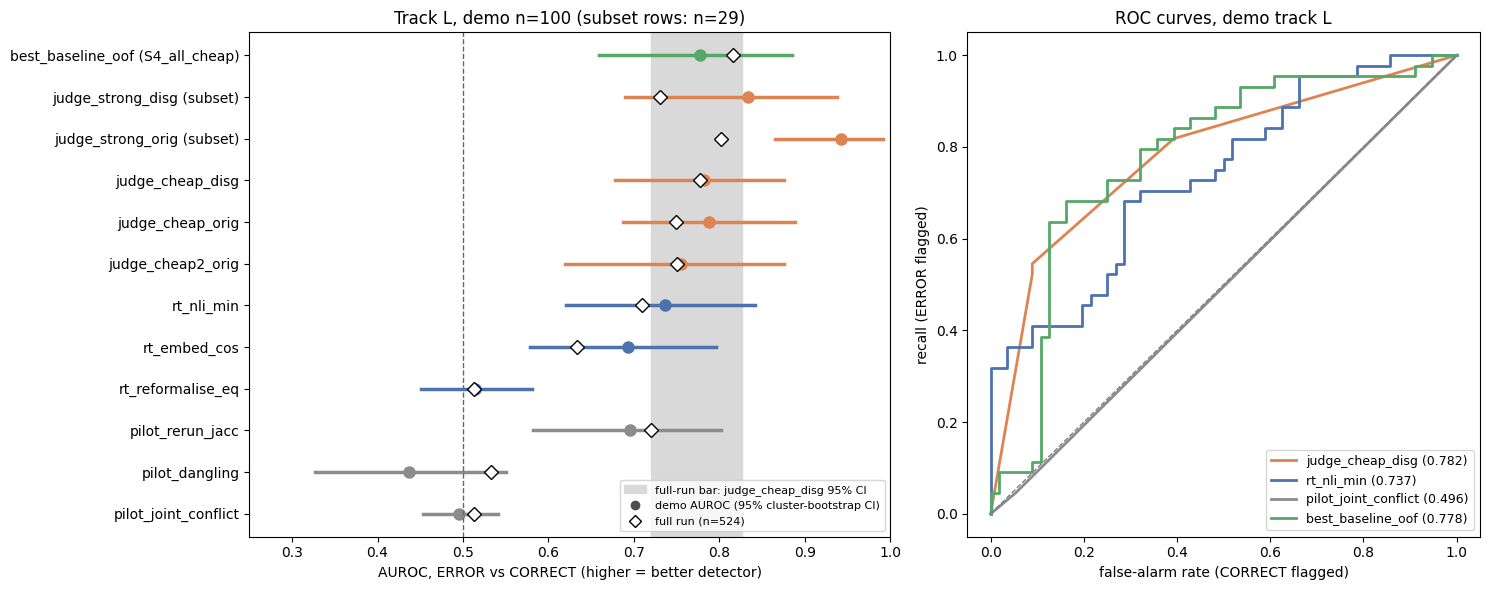

In [19]:
SHOW = ["pilot_joint_conflict", "pilot_dangling", "pilot_rerun_jacc", "rt_reformalise_eq", "rt_embed_cos", "rt_nli_min",
        "judge_cheap2_orig", "judge_cheap_orig", "judge_cheap_disg", "judge_strong_orig", "judge_strong_disg"]
full = data["metadata"]["full_run_L_primary"]
R = results["L_primary"]["metrics"]
Rs = results["L_strong_subset"]["metrics"]
rowsP = []
for m in SHOW:
    r = Rs.get(m) if m in SUBSET_METRICS else R.get(m)
    if r and r.get("auroc") is not None:
        rowsP.append((m + (" (subset)" if m in SUBSET_METRICS else ""), r["auroc"], r.get("auroc_ci"), full["auroc"][m]["auroc"]))
bl = cbL["best"]
rowsP.append((f"best_baseline_oof ({bl['set']})", bl["oof_auroc"], bl["ci"], full["best_combination"]["oof_auroc"]))

print(f"{'metric':38s} {'demo AUROC [95% CI]':26s} {'full-run AUROC':>14s}")
for name, a, c, fa in rowsP:
    print(f"{name:38s} {fmt(a, c):26s} {fa:14.3f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={"width_ratios": [1.25, 1]})
ypos = np.arange(len(rowsP))
fam_col = lambda n: "#8c8c8c" if n.startswith("pilot") else ("#4c72b0" if n.startswith("rt_") else ("#dd8452" if n.startswith("judge") else "#55a868"))
for i, (name, a, c, fa) in enumerate(rowsP):
    col = fam_col(name)
    lo, hi = (c if c and c[0] is not None else (a, a))
    ax1.plot([lo, hi], [i, i], color=col, lw=2.5)
    ax1.plot(a, i, "o", color=col, ms=8)
    ax1.plot(fa, i, "D", mfc="white", mec="black", ms=7)
bar = full["auroc"]["judge_cheap_disg"]
ax1.axvspan(bar["ci"][0], bar["ci"][1], color="0.85", zorder=0, label="full-run bar: judge_cheap_disg 95% CI")
ax1.axvline(0.5, ls="--", color="0.4", lw=1)
ax1.plot([], [], "o", color="0.3", label="demo AUROC (95% cluster-bootstrap CI)")
ax1.plot([], [], "D", mfc="white", mec="black", label=f"full run (n={full['n']})")
ax1.set_yticks(ypos, [n for n, *_ in rowsP])
ax1.set_xlabel("AUROC, ERROR vs CORRECT (higher = better detector)")
ax1.set_xlim(0.25, 1.0)
ax1.set_title(f"Track L, demo n={results['L_primary']['n']} (subset rows: n={results['L_strong_subset']['n']})")
ax1.legend(loc="lower right", fontsize=8)

keysL = [k for k, _ in sets["L_primary"]]
yL = np.array([v for _, v in sets["L_primary"]])
for m, col in (("judge_cheap_disg", "#dd8452"), ("rt_nli_min", "#4c72b0"), ("pilot_joint_conflict", "#8c8c8c")):
    s, app, _ = fill([table[m][k] for k in keysL], table["_max"][m])
    fpr, tpr, _ = roc_curve(yL[app], s[app])
    ax2.plot(fpr, tpr, color=col, lw=2, label=f"{m} ({R[m]['auroc']:.3f})")
oofL = np.array([oof_out[k]["best_baseline_oof"] for k in keysL])
fpr, tpr, _ = roc_curve(yL, oofL)
ax2.plot(fpr, tpr, color="#55a868", lw=2, label=f"best_baseline_oof ({bl['oof_auroc']:.3f})")
ax2.plot([0, 1], [0, 1], "--", color="0.5", lw=1)
ax2.set_xlabel("false-alarm rate (CORRECT flagged)")
ax2.set_ylabel("recall (ERROR flagged)")
ax2.set_title("ROC curves, demo track L")
ax2.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()